# Chapter 77 - Encoding and Decoding With the Homemade Subword Tokenizer

Chapter 76 trained ordered BPE-style merge rules from character sequences.

This chapter packages those rules into a reusable tokenizer with three operations:

```python
tokenizer.train(text)
tokenizer.encode(text)
tokenizer.decode(token_ids)
```

The implementation remains a teaching tokenizer rather than production BPE.

## Learning goals

By the end of this chapter, you will be able to:

- train a tokenizer and retain its ordered merge rules;
- build deterministic subword-to-ID and ID-to-subword mappings;
- encode text into subwords and integer token IDs;
- decode token IDs without losing spaces, punctuation, or capitalization;
- test exact round-trip correctness and deterministic encoding;
- reject unknown characters and invalid token IDs clearly; and
- explain why a model checkpoint must be paired with the tokenizer that defined its token IDs.

## The tokenizer contract

A **subword** is a token containing one or more characters.

A **merge rule** is an ordered instruction that combines one adjacent token pair.

A **vocabulary** is the set of tokens the tokenizer can represent.

The `subword_to_id` mapping assigns each vocabulary item an integer, and `id_to_subword` reverses that mapping.

**Encoding** applies the learned merges and converts the resulting subwords to IDs.

**Decoding** maps IDs back to subwords and concatenates them.

This tokenizer promises an exact **round trip** for text made from its starting alphabet:

```python
assert tokenizer.decode(tokenizer.encode(text)) == text
```

Some production tokenizers deliberately normalize text, so exact reconstruction of the pre-normalized input is not a universal tokenizer requirement.

It is the explicit contract of the tokenizer in this chapter.

## Scope and invariants

Training treats the complete string as one token sequence.

Spaces, punctuation, capitalization, and newlines are ordinary characters, so merges may cross word boundaries.

The implementation preserves these invariants:

- equal-frequency pairs use a deterministic lexical tie-break;
- every learned token remains in the cumulative vocabulary;
- merge rules are replayed in training order;
- token IDs come from a sorted vocabulary and are therefore deterministic; and
- `train()` replaces the stored state only after a complete successful training run.

This is character-initialized BPE-style tokenization, not byte-level production BPE.

It has no normalization, special tokens, byte fallback, or unknown-token fallback.

## Core merge operations

The tokenizer reuses the Chapter 76 mechanics below.

`MergeRule` records both the pair's count and the number of non-overlapping replacements, because those numbers can differ for overlapping pairs such as `("a", "a")` in `"aaa"`.

`TokenizerState` is an immutable snapshot used later to reproduce a trained tokenizer.

In [1]:
from collections import Counter
from dataclasses import dataclass
from typing import Self

TokenPair = tuple[str, str]


@dataclass(frozen=True)
class MergeRule:
    index: int
    pair: TokenPair
    new_token: str
    pair_count: int
    replacement_count: int


@dataclass(frozen=True)
class TokenizerState:
    version: int
    number_of_merges: int
    merge_rules: tuple[MergeRule, ...]
    base_alphabet: tuple[str, ...]
    subword_id_items: tuple[tuple[str, int], ...]


def count_adjacent_token_pairs(
    token_sequence: list[str],
) -> Counter[TokenPair]:
    return Counter(zip(token_sequence, token_sequence[1:], strict=False))


def select_most_frequent_pair(
    pair_counts: Counter[TokenPair],
) -> tuple[TokenPair, int]:
    if not pair_counts:
        raise ValueError("No adjacent token pairs are available.")

    highest_count = max(pair_counts.values())
    tied_pairs = [
        pair
        for pair, count in pair_counts.items()
        if count == highest_count
    ]
    return min(tied_pairs), highest_count


def merge_pair_in_sequence(
    token_sequence: list[str],
    pair_to_merge: TokenPair,
    merged_token: str,
) -> tuple[list[str], int]:
    merged_sequence: list[str] = []
    replacement_count = 0
    position = 0

    while position < len(token_sequence):
        pair_matches = (
            position + 1 < len(token_sequence)
            and token_sequence[position] == pair_to_merge[0]
            and token_sequence[position + 1] == pair_to_merge[1]
        )

        if pair_matches:
            merged_sequence.append(merged_token)
            replacement_count += 1
            position += 2
        else:
            merged_sequence.append(token_sequence[position])
            position += 1

    return merged_sequence, replacement_count


def apply_merge_rules_to_text(
    text: str,
    merge_rules: list[MergeRule],
) -> list[str]:
    token_sequence = list(text)

    for merge_rule in merge_rules:
        token_sequence, _ = merge_pair_in_sequence(
            token_sequence=token_sequence,
            pair_to_merge=merge_rule.pair,
            merged_token=merge_rule.new_token,
        )

    return token_sequence

The lexical tie-break makes training reproducible when several pairs have the same count.

The merge scan advances by two positions after a match, so one pass never applies overlapping replacements.

## A stateful tokenizer

`HomemadeSubwordTokenizer` owns the learned rules, the base alphabet, and both ID mappings.

Training first builds local values and commits them at the end.

That transactional pattern prevents a failed retraining attempt from leaving half-updated state.

In [2]:
class HomemadeSubwordTokenizer:
    number_of_merges: int
    merge_rules: list[MergeRule]
    base_alphabet: set[str]
    subword_to_id: dict[str, int]
    id_to_subword: dict[int, str]
    is_trained: bool

    def __init__(self, number_of_merges: int) -> None:
        if number_of_merges < 0:
            raise ValueError("number_of_merges must be nonnegative.")

        self.number_of_merges = number_of_merges
        self.merge_rules = []
        self.base_alphabet = set()
        self.subword_to_id = {}
        self.id_to_subword = {}
        self.is_trained = False

    def _check_trained(self) -> None:
        if not self.is_trained:
            raise RuntimeError("Tokenizer must be trained before use.")

    def _check_known_characters(self, text: str) -> None:
        unknown_characters = sorted(set(text) - self.base_alphabet)
        if unknown_characters:
            raise ValueError(
                "Text contains characters not seen during training: "
                f"{unknown_characters!r}."
            )

    def _validate_internal_state(self) -> None:
        expected_ids = set(range(len(self.subword_to_id)))
        if set(self.subword_to_id.values()) != expected_ids:
            raise ValueError("Vocabulary IDs must be unique and contiguous from zero.")

        expected_inverse = {
            token_id: subword
            for subword, token_id in self.subword_to_id.items()
        }
        if self.id_to_subword != expected_inverse:
            raise ValueError("subword_to_id and id_to_subword are not inverses.")

        vocabulary = set(self.subword_to_id)
        learned_tokens = {rule.new_token for rule in self.merge_rules}
        if not self.base_alphabet.issubset(vocabulary):
            raise ValueError("The vocabulary is missing a base character.")
        if not learned_tokens.issubset(vocabulary):
            raise ValueError("The vocabulary is missing a learned token.")
        if len(self.merge_rules) > self.number_of_merges:
            raise ValueError("The state contains more rules than requested merges.")

        for expected_index, rule in enumerate(self.merge_rules):
            if rule.index != expected_index:
                raise ValueError("Merge-rule indices must be consecutive.")
            if rule.new_token != "".join(rule.pair):
                raise ValueError("A learned token must concatenate its pair.")
            if rule.pair_count < 1 or rule.replacement_count < 1:
                raise ValueError("Merge counts must be positive.")

    def train(self, text: str) -> None:
        if not text:
            raise ValueError("Training text must not be empty.")

        token_sequence = list(text)
        base_alphabet = set(token_sequence)
        vocabulary = set(base_alphabet)
        merge_rules: list[MergeRule] = []

        for merge_index in range(self.number_of_merges):
            pair_counts = count_adjacent_token_pairs(token_sequence)
            if not pair_counts:
                break

            pair_to_merge, pair_count = select_most_frequent_pair(pair_counts)
            new_token = "".join(pair_to_merge)
            if new_token in vocabulary:
                raise RuntimeError(
                    f"Merge would collide with existing token {new_token!r}."
                )

            token_sequence, replacement_count = merge_pair_in_sequence(
                token_sequence=token_sequence,
                pair_to_merge=pair_to_merge,
                merged_token=new_token,
            )
            merge_rules.append(
                MergeRule(
                    index=merge_index,
                    pair=pair_to_merge,
                    new_token=new_token,
                    pair_count=pair_count,
                    replacement_count=replacement_count,
                )
            )
            vocabulary.add(new_token)

        sorted_vocabulary = sorted(vocabulary)
        subword_to_id = {
            subword: token_id
            for token_id, subword in enumerate(sorted_vocabulary)
        }
        id_to_subword = {
            token_id: subword
            for subword, token_id in subword_to_id.items()
        }

        self.merge_rules = merge_rules
        self.base_alphabet = base_alphabet
        self.subword_to_id = subword_to_id
        self.id_to_subword = id_to_subword
        self.is_trained = True
        self._validate_internal_state()

    def encode_to_subwords(self, text: str) -> list[str]:
        self._check_trained()
        self._check_known_characters(text)
        return apply_merge_rules_to_text(text, self.merge_rules)

    def encode(self, text: str) -> list[int]:
        subwords = self.encode_to_subwords(text)
        return [self.subword_to_id[subword] for subword in subwords]

    def decode(self, token_ids: list[int]) -> str:
        self._check_trained()
        invalid_token_ids = sorted(set(token_ids) - set(self.id_to_subword))
        if invalid_token_ids:
            raise ValueError(f"Unknown token IDs: {invalid_token_ids!r}.")

        return "".join(self.id_to_subword[token_id] for token_id in token_ids)

    def get_state(self) -> TokenizerState:
        self._check_trained()
        subword_id_items = tuple(
            sorted(self.subword_to_id.items(), key=lambda item: item[1])
        )
        return TokenizerState(
            version=1,
            number_of_merges=self.number_of_merges,
            merge_rules=tuple(self.merge_rules),
            base_alphabet=tuple(sorted(self.base_alphabet)),
            subword_id_items=subword_id_items,
        )

    @classmethod
    def from_state(cls, state: TokenizerState) -> Self:
        if state.version != 1:
            raise ValueError(f"Unsupported tokenizer-state version {state.version}.")

        tokenizer = cls(number_of_merges=state.number_of_merges)
        tokenizer.merge_rules = list(state.merge_rules)
        tokenizer.base_alphabet = set(state.base_alphabet)
        tokenizer.subword_to_id = dict(state.subword_id_items)
        tokenizer.id_to_subword = {
            token_id: subword
            for subword, token_id in tokenizer.subword_to_id.items()
        }
        tokenizer.is_trained = True
        tokenizer._validate_internal_state()
        return tokenizer

The vocabulary retains every starting character and every token created by a merge, even if a smaller token no longer appears in the final training segmentation.

This cumulative vocabulary is necessary because a new input may stop matching after any earlier merge.

## Train and inspect the learned state

The example contains repeated phrases, spaces, punctuation, capitalization, and a newline.

Those characters let later tests verify that decoding preserves more than letters alone.

In [3]:
training_text = "The cat sat on the mat. The cat sat.\nThe mat sat."

tokenizer = HomemadeSubwordTokenizer(number_of_merges=24)
tokenizer.train(training_text)

print("Requested merges:", tokenizer.number_of_merges)
print("Learned merges:", len(tokenizer.merge_rules))
print("Base alphabet size:", len(tokenizer.base_alphabet))
print("Vocabulary size:", len(tokenizer.subword_to_id))
print()
print("Learned merge rules:")
for rule in tokenizer.merge_rules:
    print(
        f"{rule.index:>2}: {rule.pair!r} -> {rule.new_token!r} "
        f"(pair count {rule.pair_count}, replacements {rule.replacement_count})"
    )

Requested merges: 24
Learned merges: 24
Base alphabet size: 13
Vocabulary size: 37

Learned merge rules:
 0: ('a', 't') -> 'at' (pair count 7, replacements 7)
 1: ('at', ' ') -> 'at ' (pair count 4, replacements 4)
 2: ('e', ' ') -> 'e ' (pair count 4, replacements 4)
 3: ('h', 'e ') -> 'he ' (pair count 4, replacements 4)
 4: ('T', 'he ') -> 'The ' (pair count 3, replacements 3)
 5: ('at', '.') -> 'at.' (pair count 3, replacements 3)
 6: ('at ', 's') -> 'at s' (pair count 3, replacements 3)
 7: ('The ', 'c') -> 'The c' (pair count 2, replacements 2)
 8: ('The c', 'at s') -> 'The cat s' (pair count 2, replacements 2)
 9: ('\n', 'The ') -> '\nThe ' (pair count 1, replacements 1)
10: ('\nThe ', 'm') -> '\nThe m' (pair count 1, replacements 1)
11: ('\nThe m', 'at s') -> '\nThe mat s' (pair count 1, replacements 1)
12: ('\nThe mat s', 'at.') -> '\nThe mat sat.' (pair count 1, replacements 1)
13: (' ', 'The cat s') -> ' The cat s' (pair count 1, replacements 1)
14: (' ', 't') -> ' t' (pair 

Frequent local patterns become progressively larger tokens.

Tokens containing spaces or punctuation are valid because the training representation did not discard those characters.

The ID table below is deterministic because IDs are assigned after sorting the cumulative vocabulary.

`repr()` keeps whitespace-bearing tokens visible.

In [4]:
print("token ID | subword")
print("-" * 34)
for token_id, subword in tokenizer.id_to_subword.items():
    print(f"{token_id:>8} | {subword!r}")

token ID | subword
----------------------------------
       0 | '\n'
       1 | '\nThe '
       2 | '\nThe m'
       3 | '\nThe mat s'
       4 | '\nThe mat sat.'
       5 | ' '
       6 | ' The cat s'
       7 | ' The cat sat.'
       8 | ' The cat sat.\nThe mat sat.'
       9 | ' t'
      10 | ' the '
      11 | ' the m'
      12 | ' the mat.'
      13 | ' the mat. The cat sat.\nThe mat sat.'
      14 | '.'
      15 | 'T'
      16 | 'The '
      17 | 'The c'
      18 | 'The cat s'
      19 | 'The cat sat '
      20 | 'The cat sat o'
      21 | 'The cat sat on'
      22 | 'a'
      23 | 'at'
      24 | 'at '
      25 | 'at s'
      26 | 'at.'
      27 | 'c'
      28 | 'e'
      29 | 'e '
      30 | 'h'
      31 | 'he '
      32 | 'm'
      33 | 'n'
      34 | 'o'
      35 | 's'
      36 | 't'


## Encode, decode, and check the round trip

Encoding first exposes the subword segmentation and then maps those subwords to integers.

Decoding performs only the inverse ID lookup and string concatenation.

It must not insert spaces because some learned tokens already contain spaces.

In [5]:
original_text = "The cat sat"
encoded_subwords = tokenizer.encode_to_subwords(original_text)
encoded_token_ids = tokenizer.encode(original_text)
decoded_text = tokenizer.decode(encoded_token_ids)

print("Original text:", repr(original_text))
print("Encoded subwords:", encoded_subwords)
print("Encoded token IDs:", encoded_token_ids)
print("Decoded text:", repr(decoded_text))

assert decoded_text == original_text
print("Exact round trip passed.")

Original text: 'The cat sat'
Encoded subwords: ['The cat s', 'at']
Encoded token IDs: [18, 23]
Decoded text: 'The cat sat'
Exact round trip passed.


One successful example is not enough.

The next helper checks ordinary phrases, punctuation, a newline, text without spaces, and the empty string.

The empty string is valid input after training and round-trips through an empty ID sequence.

In [6]:
def assert_round_trip_correctness(
    tokenizer_to_test: HomemadeSubwordTokenizer,
    text: str,
) -> None:
    token_ids = tokenizer_to_test.encode(text)
    decoded_text = tokenizer_to_test.decode(token_ids)
    if decoded_text != text:
        raise AssertionError(
            "Round-trip correctness failed.\n"
            f"Original: {text!r}\n"
            f"Decoded:  {decoded_text!r}\n"
            f"IDs:      {token_ids!r}"
        )


round_trip_examples = [
    "The cat sat",
    "The mat.",
    "thecat",
    "The cat sat.\nThe mat sat.",
    "",
]

for example_text in round_trip_examples:
    assert_round_trip_correctness(tokenizer, example_text)
    print("passed:", repr(example_text))

passed: 'The cat sat'
passed: 'The mat.'
passed: 'thecat'
passed: 'The cat sat.\nThe mat sat.'
passed: ''


The tests establish exact reconstruction for inputs whose characters belong to the training alphabet.

They do not prove that the chosen segmentation is optimal for a language model.

## Preserve distinctions in the source text

Spaces, punctuation, and capitalization change the input string and therefore must survive decoding.

The token sequences may differ in length, but each one must recover its own source exactly.

In [7]:
text_variants = [
    "The cat",
    "Thecat",
    "The cat.",
    "the cat",
]

for text_variant in text_variants:
    token_ids = tokenizer.encode(text_variant)
    decoded_variant = tokenizer.decode(token_ids)
    assert decoded_variant == text_variant
    print(
        f"{text_variant!r:<12} -> "
        f"{tokenizer.encode_to_subwords(text_variant)!r} -> "
        f"{decoded_variant!r}"
    )

'The cat'    -> ['The c', 'at'] -> 'The cat'
'Thecat'     -> ['T', 'h', 'e', 'c', 'at'] -> 'Thecat'
'The cat.'   -> ['The c', 'at.'] -> 'The cat.'
'the cat'    -> ['t', 'he ', 'c', 'at'] -> 'the cat'


Lowercasing, removing punctuation, or collapsing whitespace would make this tokenizer lossy.

Such normalization can be intentional in another system, but its contract and training data must then reflect that decision.

## Reject invalid input without corrupting state

This teaching tokenizer has no byte or unknown-token fallback.

It therefore rejects a character outside the stored base alphabet and rejects an ID outside the vocabulary.

It also rejects use before training.

In [8]:
untrained_tokenizer = HomemadeSubwordTokenizer(number_of_merges=4)

try:
    untrained_tokenizer.encode("The cat")
except RuntimeError as error:
    print("Untrained use:", error)

try:
    tokenizer.encode("The Cat")
except ValueError as error:
    print("Unknown character:", error)

invalid_token_id = len(tokenizer.id_to_subword)
try:
    tokenizer.decode([invalid_token_id])
except ValueError as error:
    print("Invalid token ID:", error)

state_before_failed_training = tokenizer.get_state()
try:
    tokenizer.train("")
except ValueError as error:
    print("Failed retraining:", error)

assert tokenizer.get_state() == state_before_failed_training
print("Existing state remained unchanged.")

Untrained use: Tokenizer must be trained before use.
Unknown character: Text contains characters not seen during training: ['C'].
Invalid token ID: Unknown token IDs: [37].
Failed retraining: Training text must not be empty.
Existing state remained unchanged.


The failed retraining check demonstrates the transactional guarantee rather than merely describing it.

## Merge order is part of the tokenizer

A later rule can depend on a token created by an earlier rule.

Reversing the rules can therefore produce a different segmentation even though concatenating either segmentation still recovers the characters.

In [9]:
def encode_with_reversed_merge_order(
    text: str,
    merge_rules: list[MergeRule],
) -> list[str]:
    token_sequence = list(text)

    for merge_rule in reversed(merge_rules):
        token_sequence, _ = merge_pair_in_sequence(
            token_sequence=token_sequence,
            pair_to_merge=merge_rule.pair,
            merged_token=merge_rule.new_token,
        )

    return token_sequence


merge_order_example = "The cat sat"
correct_subwords = tokenizer.encode_to_subwords(merge_order_example)
reversed_subwords = encode_with_reversed_merge_order(
    merge_order_example,
    tokenizer.merge_rules,
)

print("Correct order:", correct_subwords)
print("Reversed order:", reversed_subwords)
print("Segmentations differ:", correct_subwords != reversed_subwords)

assert "".join(correct_subwords) == merge_order_example
assert "".join(reversed_subwords) == merge_order_example
assert correct_subwords != reversed_subwords

Correct order: ['The cat s', 'at']
Reversed order: ['T', 'h', 'e ', 'c', 'at', ' ', 's', 'at']
Segmentations differ: True


Both lists preserve the string, but only the learned order produces the vocabulary segmentation used to assign IDs and train a model.

The ordered merge list is therefore part of the tokenizer's learned state, not an unordered set.

## Measure sequence shortening

The plot compares one-token-per-character input with the learned subword segmentation.

Fewer tokens can reduce the sequence length presented to a GPT, although this toy corpus is too small to establish a useful production vocabulary.

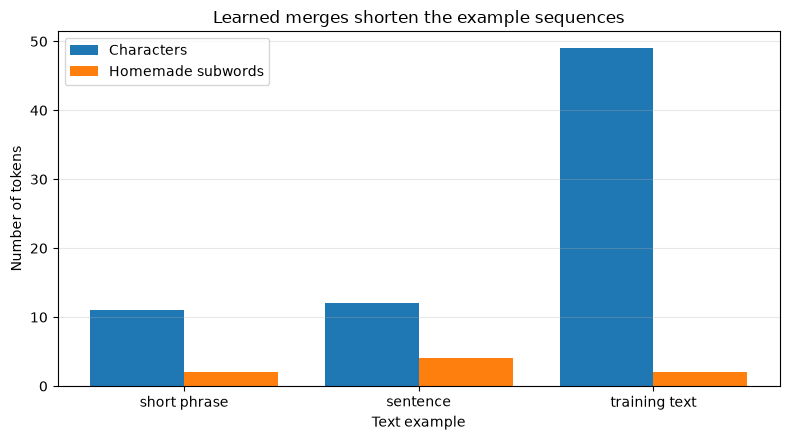

In [10]:
import matplotlib.pyplot as plt

comparison_texts = [
    "The cat sat",
    "The mat sat.",
    training_text,
]
character_lengths = [len(text) for text in comparison_texts]
subword_lengths = [
    len(tokenizer.encode_to_subwords(text))
    for text in comparison_texts
]
positions = list(range(len(comparison_texts)))

figure, axis = plt.subplots(figsize=(8, 4.5))
axis.bar(
    [position - 0.2 for position in positions],
    character_lengths,
    width=0.4,
    label="Characters",
)
axis.bar(
    [position + 0.2 for position in positions],
    subword_lengths,
    width=0.4,
    label="Homemade subwords",
)
axis.set_xticks(positions, ["short phrase", "sentence", "training text"])
axis.set_xlabel("Text example")
axis.set_ylabel("Number of tokens")
axis.set_title("Learned merges shorten the example sequences")
axis.legend()
axis.grid(axis="y", alpha=0.3)
figure.tight_layout()
plt.show()

The learned representation is shorter for these repeated, in-domain examples.

More merges generally trade a larger embedding and output vocabulary for shorter sequences, but fewer tokens do not by themselves guarantee a better model.

## Deterministic encoding and state restoration

The same tokenizer state must always assign the same IDs to the same text.

An immutable `TokenizerState` snapshot lets a checkpoint restore that exact interpretation without exposing mutable internal dictionaries.

In [11]:
determinism_text = "The cat sat"
repeated_encodings = [
    tokenizer.encode(determinism_text)
    for _ in range(3)
]
assert repeated_encodings[0] == repeated_encodings[1] == repeated_encodings[2]

tokenizer_state = tokenizer.get_state()
restored_tokenizer = HomemadeSubwordTokenizer.from_state(tokenizer_state)

restored_ids = restored_tokenizer.encode(determinism_text)
assert restored_ids == repeated_encodings[0]
assert restored_tokenizer.decode(restored_ids) == determinism_text
assert restored_tokenizer.get_state() == tokenizer_state

print("Repeated encoding:", repeated_encodings[0])
print("State version:", tokenizer_state.version)
print("Restored vocabulary size:", len(restored_tokenizer.subword_to_id))
print("Restored tokenizer round trip passed.")

Repeated encoding: [18, 23]
State version: 1
Restored vocabulary size: 37
Restored tokenizer round trip passed.


## Why the model and tokenizer must match

A GPT learns an embedding and an output score for each token ID.

If ID `7` meant `"the"` during training but a different tokenizer maps ID `7` to `"cat"`, the saved parameters are interpreted incorrectly.

A usable model checkpoint must therefore retain or identify:

- the ordered merge rules;
- the base alphabet and any special-token policy;
- the exact subword-to-ID mapping; and
- the tokenizer format version.

The tokenizer is part of the model system rather than disposable preprocessing.

## Common mistakes

- Do not apply merge rules as an unordered set or in reverse.
- Do not rebuild IDs from a different vocabulary order after model training.
- Do not decode by inserting separators between subwords.
- Do not silently remove spaces, punctuation, capitalization, or newlines when exact reconstruction is the contract.
- Do not treat an unknown-character error as impossible; this tokenizer deliberately lacks a fallback.
- Do not conclude that a tokenizer is good merely because its round trip is exact.

Exact reconstruction checks information preservation, while language-model usefulness also depends on segmentation quality, vocabulary size, corpus coverage, and model scale.

## Takeaways

The homemade tokenizer now supports a complete deterministic interface:

```python
tokenizer.train(text)
token_ids = tokenizer.encode(text)
decoded_text = tokenizer.decode(token_ids)
```

Its ordered merge rules determine segmentation, and its two mappings determine the meaning of each integer ID.

For known characters, the central correctness check is:

```python
assert tokenizer.decode(tokenizer.encode(text)) == text
```

Round-trip correctness prevents accidental information loss, while saved tokenizer state keeps a trained model's token meanings stable.

## What comes next

The next chapter can replace character IDs with these subword IDs in GPT-style input-target batches.

The transformer architecture can remain the same, but its vocabulary size and the token sequences it learns from will now come from this tokenizer.